In [1]:
import glob
import itertools
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns

In [2]:
# Load weights

results_dir = '../rnn_results/aidan_sigma/'

all_dirs = glob.glob(results_dir + 'zeroint*_delay*_normal_eta*_sigma*')

found_zeroint   = {f.split('zeroint')[-1].split('_')[0]  for f in all_dirs}
found_delays    = {f.split('delay')[-1].split('_')[0]    for f in all_dirs}
found_etas      = {f.split('eta')[-1].split('_')[0]      for f in all_dirs}
found_sigmas    = {f.split('sigma')[-1].split('_')[0]    for f in all_dirs}

separated_dirs = {}

for zeroint, delay, eta, sigma in itertools.product(
        found_zeroint, found_delays, found_etas, found_sigmas):

    key = ('zeroint'  + zeroint,
           'delay'    + delay,
           'sigma'    + sigma,
           'eta'      + eta)

    separated_dirs[key] = [
        f for f in all_dirs
        if (f'zeroint{zeroint}_'     in f
            and f'delay{delay}_'     in f
            and f'sigma{sigma}_'    in f
            and f'eta{eta}_'         in f)
    ]

weights = {'rnn': {}, 'rec': {}, 'input': {}, 'output': {}, 'tau': {}}

for zeroint, delay, eta, sigma in itertools.product(
        found_zeroint, found_delays, found_etas, found_sigmas):

    key = ('zeroint'  + zeroint,
           'delay'    + delay,
           'sigma'    + sigma,
           'eta'      + eta)

    filepaths = separated_dirs[key]
    for wk in weights:
        weights[wk][key] = []

    for filepath in filepaths:
        rnn = torch.load(filepath + '/best_model.pth')
        weights['rnn'][key].append(rnn)
        weights['rec'][key].append(rnn['hh.weight'])
        weights['input'][key].append(rnn['ih.weight'])
        weights['output'][key].append(rnn['ho.weight'])
        weights['tau'][key].append(rnn['taus'])

    for wk in weights:
        weights[wk][key] = np.array(weights[wk][key])

# Load vanilla weights (eta=0) seperately

vanilla_dirs = glob.glob(results_dir + 'zeroint*_delay*_vanilla1.0*_sigma*')

# Parse vanilla dirs — extract same fields, hardcode eta='0.0'
for d in vanilla_dirs:
    zeroint  = d.split('zeroint')[-1].split('_')[0]
    delay    = d.split('delay')[-1].split('_')[0]
    sigma    = d.split('sigma')[-1].split('_')[0]

    key = (f'zeroint{zeroint}', f'delay{delay}', f'sigma{sigma}', 'eta0.0')

    if key not in separated_dirs:
        separated_dirs[key] = []
    separated_dirs[key].append(d)

# Load vanilla weights into weights dict
for d in vanilla_dirs:
    zeroint  = d.split('zeroint')[-1].split('_')[0]
    delay    = d.split('delay')[-1].split('_')[0]
    sigma    = d.split('sigma')[-1].split('_')[0]

    key = (f'zeroint{zeroint}', f'delay{delay}', f'sigma{sigma}', 'eta0.0')

    if key not in weights['rnn']:
        for wk in weights:
            weights[wk][key] = []

    rnn = torch.load(d + '/best_model.pth')
    weights['rnn'][key].append(rnn)
    weights['rec'][key].append(rnn['hh.weight'])
    weights['input'][key].append(rnn['ih.weight'])
    weights['output'][key].append(rnn['ho.weight'])
    weights['tau'][key].append(rnn['taus'])

for d in vanilla_dirs:
    autocorr = d.split('autocorr')[-1].split('_')[0]
    ktau     = d.split('ktau')[-1].split('_')[0]
    zeroint  = d.split('zeroint')[-1].split('_')[0]
    delay    = d.split('delay')[-1].split('_')[0]
    key = (f'zeroint{zeroint}', f'delay{delay}', f'sigma{sigma}', 'eta0.0')

for wk in weights:
    weights[wk][key] = np.array(weights[wk][key])

In [3]:
def _frob_normalize(hh):
    # hh: (n_fits, N, N)
    scales = np.linalg.norm(hh, axis=(1,2), keepdims=True)
    hh_norm = hh / scales
    return hh_norm

def bin_and_average_rec_weights(weights, key, n_bins=20):
    hh_all = weights['rec'][key]
    hh_norm = _frob_normalize(hh_all)
    taus_all = weights['tau'][key]

    n_seeds = hh_all.shape[0]
    out = np.zeros((n_seeds, n_bins, n_bins))

    for f in range(n_seeds):
        hh = hh_norm[f]
        taus = taus_all[f]

        # quantile binning (frequency-based)
        edges = np.quantile(taus, np.linspace(0, 1, n_bins + 1))
        edges = np.unique(edges)

        # assign bins
        bin_idx = np.digitize(taus, edges[1:-1])

        # preprocess weights
        hh_proc = np.abs(hh)
        np.fill_diagonal(hh_proc, np.nan)

        for i in range(n_bins):
            src = np.where(bin_idx == i)[0]
            if len(src) == 0:
                continue

            for j in range(n_bins):
                tgt = np.where(bin_idx == j)[0]
                if len(tgt) == 0:
                    continue

                out[f, j, i] = np.nanmean(
                    hh_proc[np.ix_(tgt, src)]
                )

    final_mat = np.nanmean(out, axis=0)

    return final_mat, edges

('zerointFalse', 'delay2.0', 'sigma0.1', 'eta0.1')


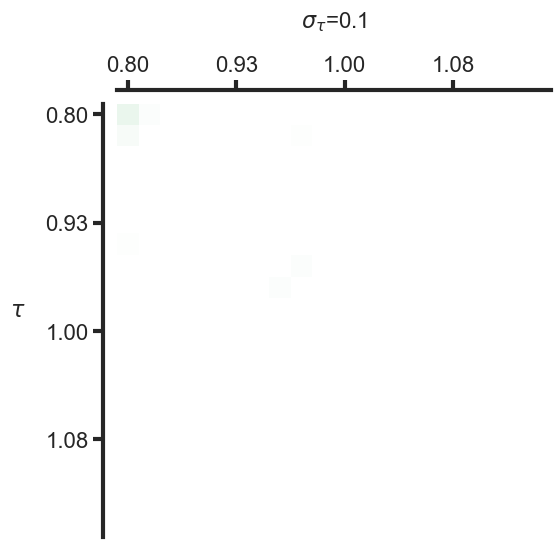

('zerointFalse', 'delay2.0', 'sigma0.1', 'eta0.25')


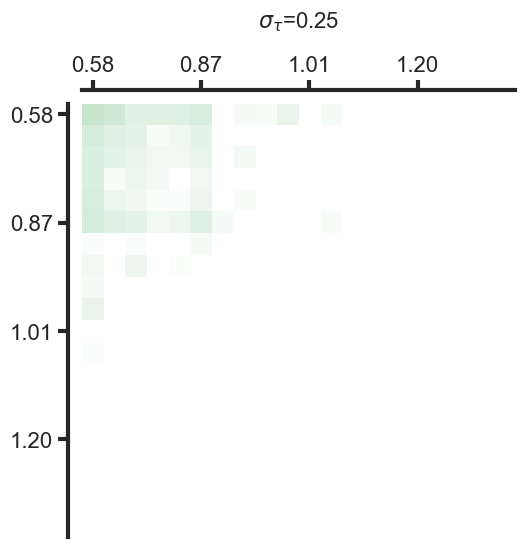

('zerointFalse', 'delay2.0', 'sigma0.1', 'eta0.5')


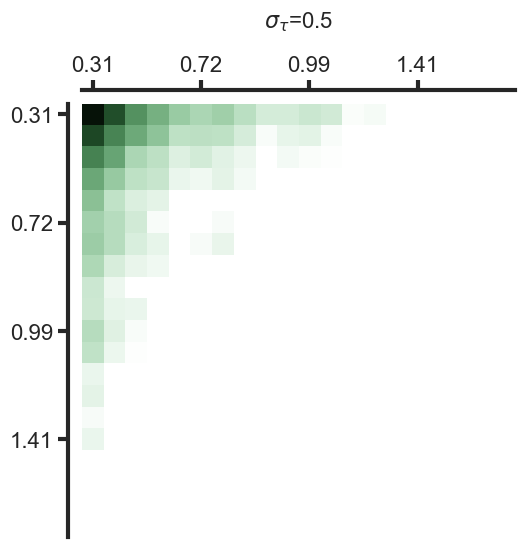

('zerointFalse', 'delay2.0', 'sigma0.1', 'eta1.0')


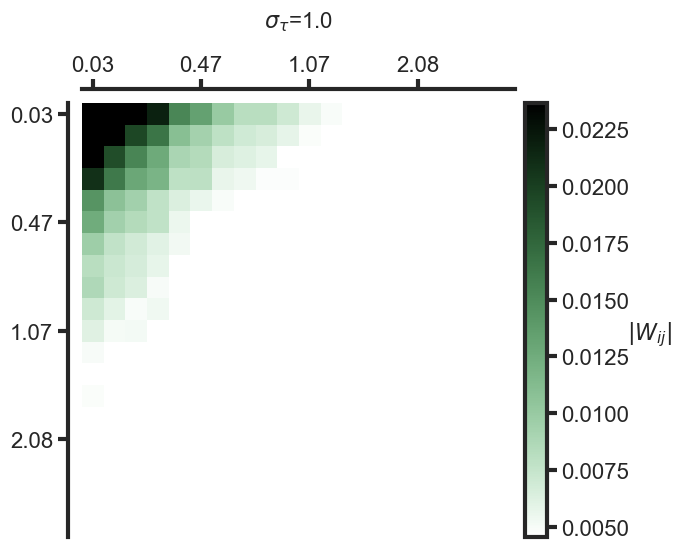

In [16]:
sns.set_theme(
    style="ticks",
    rc={
        "axes.spines.right": True,
        "axes.spines.top": True,
        
        # Axes and line tickness
        'axes.linewidth': 3,
        "lines.linewidth": 2,
        
        # Tick thickness
        "xtick.major.width": 3,
        "ytick.major.width": 3,

        # Tick length
        "xtick.major.size": 7,
        "ytick.major.size": 7,
        
        # Font size
        "font.size": 16,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
    }
)

etas = [0.1, 0.25, 0.5, 1.0]
min_vals = []
max_vals = []

for idx, eta, in enumerate(etas):
    key = ('zerointFalse', 'delay0.0', f'sigma0.1', f'eta{eta}')
    final_mat, _ = bin_and_average_rec_weights(weights, key)
    min_vals.append(final_mat.min())
    max_vals.append(final_mat.max())

from mpl_toolkits.axes_grid1 import make_axes_locatable

for idx, eta in enumerate(etas):
    key = ('zerointFalse', 'delay2.0', f'sigma0.1', f'eta{eta}')
    print(key)

    final_mat, taus = bin_and_average_rec_weights(weights, key)

    fig, ax = plt.subplots(figsize=(6,6))
    ax.set_title(rf'$\sigma_\tau$={eta}', pad=20)

    
    im = ax.imshow(
        final_mat,
        cmap=sns.cubehelix_palette(start=2, rot=0, dark=0, light=1, reverse=False, as_cmap=True),
        interpolation='nearest',
        vmin=np.min(min_vals),
        vmax=np.max(max_vals)
    )

    # --- spine styling ---
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_position(('outward', 10))
    ax.spines['left'].set_position(('outward', 10))

    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.tick_params(bottom=False, labelbottom=False)
    
    if idx==0:
        ax.set_ylabel(r'$\tau$', rotation=0, labelpad=20)

    ticks = [0, 5, 10, 15]

    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    labels = [f"{taus[i]:.2f}" for i in ticks]

    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # --- create a consistent colorbar axis ---
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)

    if idx == len(etas) - 1:
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(r'$|W_{ij}|$', rotation=0, labelpad=15)
    else:
        # keep space but hide it
        cax.set_visible(False)

    plt.show()

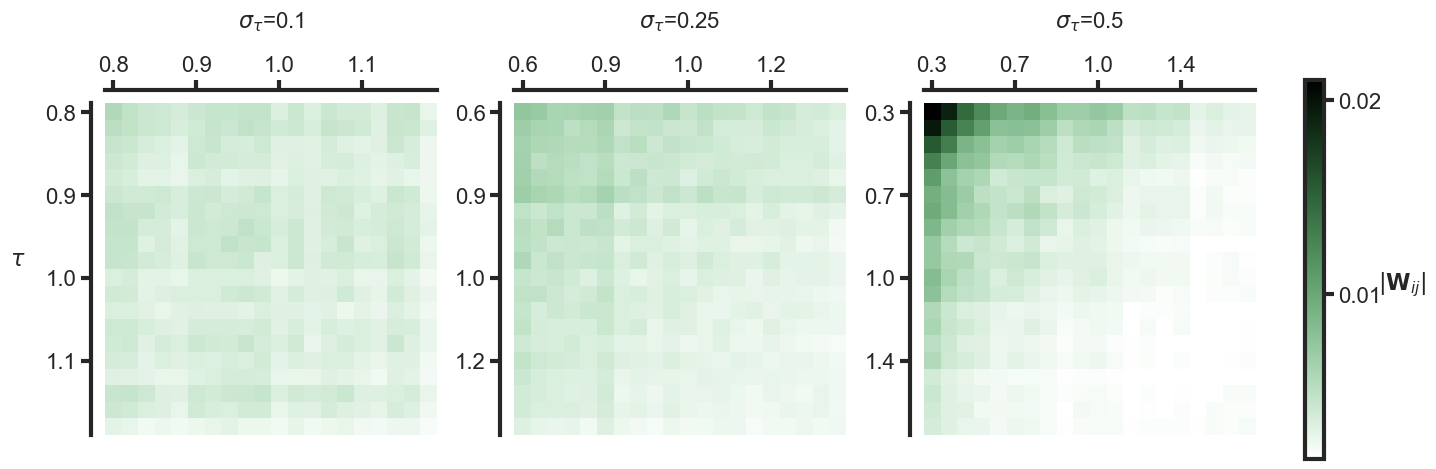

In [37]:
etas = [0.1, 0.25, 0.5]

# --- get global color scale ---
min_vals, max_vals = [], []
for eta in etas:
    key = ('zerointFalse', 'delay2.0', f'sigma0.01', f'eta{eta}')
    final_mat, _ = bin_and_average_rec_weights(weights, key)
    min_vals.append(final_mat.min())
    max_vals.append(final_mat.max())

vmin = np.min(min_vals)
vmax = np.max(max_vals)

# --- create subplots ---
fig, axes = plt.subplots(1, len(etas), figsize=(15, 5))

# --- colormap ---
cmap = sns.cubehelix_palette(start=2, rot=0, dark=0, light=1,
                             reverse=False, as_cmap=True)

for idx, (ax, eta) in enumerate(zip(axes, etas)):
    key = ('zerointFalse', 'delay2.0', f'sigma0.1', f'eta{eta}')
    final_mat, taus = bin_and_average_rec_weights(weights, key)

    im = ax.imshow(
        final_mat,
        cmap=cmap,
        interpolation='nearest',
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(rf'$\sigma_\tau$={eta}', pad=20)

    # --- spine styling ---
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_position(('outward', 10))
    ax.spines['left'].set_position(('outward', 10))

    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.tick_params(bottom=False, labelbottom=False)

    # --- ticks + tau labels ---
    ticks = [0, 5, 10, 15]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    labels = [f"{taus[i]:.1f}" for i in ticks]
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # only leftmost gets y-label
    if idx == 0:
        ax.set_ylabel(r'$\tau$', rotation=0, labelpad=20)

# WEleave space for colorbar BEFORE adding it
plt.tight_layout(rect=[0, 0, 0.92, 1])

# shared colorbar with explicit padding
cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.04, format="%.2f",
                    ticks=[0.01, 0.02, 0.03, 0.04, 0.05])
cbar.set_label(r'$|\mathbf{W}_{ij}|$', rotation=0, labelpad=15)